# X-Pathology Colon Specialist: v6 (More Structured pipeline + fixed Grad-CAM++)

In [1]:
!pip install -q -U timm albumentations huggingface_hub 2>/dev/null
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 46.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 91.3 MB/s eta 0:00:00:00:01
Dependencies installed.


In [2]:
import os
import gc
import json
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.optimize import minimize_scalar

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

import timm
from timm.layers.helpers import to_2tuple
import albumentations as A
from tqdm.auto import tqdm

cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)
torch.backends.cudnn.benchmark = True

### Config

In [3]:
NCT100K_DIR  = '/kaggle/input/datasets/imrankhan77/nct-crc-he-100k/NCT-CRC-HE-100K'
CRCVAL7K_DIR = '/kaggle/input/datasets/imrankhan77/crc-val-he-7k/CRC-VAL-HE-7K'

CHECKPOINT_PATH = '/kaggle/working/xpathology_colon_ctranspath_v6.pt'
CSV_LOG_PATH    = '/kaggle/working/training_log_ctranspath_v6.csv'

CLASS_NAMES = ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 224

BATCH_SIZE_PER_GPU = 64
NUM_WORKERS        = 4

EPOCHS_PHASE1      = 8
EPOCHS_PHASE2      = 15
LR_PHASE1          = 1e-3
LR_PHASE2_BACKBONE = 1e-5
LR_PHASE2_HEAD     = 2e-4
WEIGHT_DECAY       = 0.01
LABEL_SMOOTHING    = 0.1
DROPOUT_RATE       = 0.3
FINE_TUNE_STAGES   = 2
GRAD_CLIP_NORM     = 1.0
EARLY_STOP_PATIENCE = 5
VAL_HOLDOUT_SPLIT  = 0.5
RANDOM_SEED        = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f"Device: {device} | GPUs available: {n_gpus}")
for i in range(n_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Device: cuda | GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


### Splits: "no leakage", full NCT-100K for training, CRC-VAL-HE-7K for val/test

In [4]:
def list_files_by_class(root_dir, class_names):
    files, labels = [], []
    for i, cname in enumerate(class_names):
        class_dir = os.path.join(root_dir, cname)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: {class_dir} not found, skipping")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg')):
                files.append(os.path.join(class_dir, fname))
                labels.append(i)
    return files, labels

train_files, train_labels = list_files_by_class(NCT100K_DIR, CLASS_NAMES)
holdout_files, holdout_labels = list_files_by_class(CRCVAL7K_DIR, CLASS_NAMES)

val_files, test_files, val_labels, test_labels = train_test_split(
    holdout_files, holdout_labels,
    test_size=(1 - VAL_HOLDOUT_SPLIT),
    stratify=holdout_labels,
    random_state=RANDOM_SEED
)

print(f"Train samples (NCT-CRC-HE-100K): {len(train_files)}")
print(f"Val samples   (CRC-VAL-HE-7K):   {len(val_files)}")
print(f"Test samples  (CRC-VAL-HE-7K):   {len(test_files)}")

class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=np.arange(NUM_CLASSES), y=train_labels
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

print("\nClass distribution & weights:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name:<6} Count: {class_counts[i]:>6} | Weight: {class_weights_array[i]:.4f}")

Train samples (NCT-CRC-HE-100K): 100000
Val samples   (CRC-VAL-HE-7K):   3590
Test samples  (CRC-VAL-HE-7K):   3590

Class distribution & weights:
  [0] ADI    Count:  10407 | Weight: 1.0677
  [1] BACK   Count:  10566 | Weight: 1.0516
  [2] DEB    Count:  11512 | Weight: 0.9652
  [3] LYM    Count:  11557 | Weight: 0.9614
  [4] MUC    Count:   8896 | Weight: 1.2490
  [5] MUS    Count:  13536 | Weight: 0.8209
  [6] NORM   Count:   8763 | Weight: 1.2680
  [7] STR    Count:  10446 | Weight: 1.0637
  [8] TUM    Count:  14317 | Weight: 0.7761


### CTransPath model -- ConvStem patch embed, frozen-BatchNorm handled correctly

In [5]:
class ConvStem(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=768, norm_layer=None, **kwargs):
        super().__init__()
        assert patch_size == 4, "Patch size must be 4"
        assert embed_dim % 8 == 0, "Embedding dimension must be a multiple of 8"

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = (img_size[0] // patch_size[0], img_size[1] // patch_size[1])
        self.num_patches = self.grid_size[0] * self.grid_size[1]

        stem = []
        input_dim, output_dim = 3, embed_dim // 8
        for _ in range(2):
            stem.append(nn.Conv2d(input_dim, output_dim, kernel_size=3, stride=2, padding=1, bias=False))
            stem.append(nn.BatchNorm2d(output_dim))
            stem.append(nn.ReLU(inplace=True))
            input_dim = output_dim
            output_dim *= 2
        stem.append(nn.Conv2d(input_dim, embed_dim, kernel_size=1))
        self.proj = nn.Sequential(*stem)
        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}x{W}) doesn't match model ({self.img_size[0]}x{self.img_size[1]})."
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        return x


class CTransPathColonClassifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            "hf-hub:1aurent/swin_tiny_patch4_window7_224.CTransPath",
            embed_layer=ConvStem,
            pretrained=True,
            num_classes=0,
        )
        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout_rate),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout_rate * 0.75),
            nn.Linear(256, num_classes),
        )
        self.last_feature_map = None

    def forward(self, x, capture_map=False):
        feat_map = self.backbone.forward_features(x)
        if capture_map:
            feat_map.retain_grad()
            self.last_feature_map = feat_map
        pooled = feat_map.mean(dim=(1, 2))
        logits = self.head(pooled)
        return logits

    def train(self, mode=True):
        super().train(mode)
        if mode and hasattr(self.backbone, 'patch_embed'):
            if not any(p.requires_grad for p in self.backbone.patch_embed.parameters()):
                self.backbone.patch_embed.eval()
        return self


def freeze_backbone(model):
    for p in model.backbone.parameters():
        p.requires_grad = False

def unfreeze_top_stages(model, n_stages):
    for p in model.backbone.parameters():
        p.requires_grad = False
    total_stages = len(model.backbone.layers)
    for stage in model.backbone.layers[total_stages - n_stages:]:
        for p in stage.parameters():
            p.requires_grad = True
    for p in model.backbone.norm.parameters():
        p.requires_grad = True
    return total_stages

base_model = CTransPathColonClassifier(NUM_CLASSES, dropout_rate=DROPOUT_RATE).to(device)
print(f"Feature dim: {base_model.backbone.num_features} | Swin stages: {len(base_model.backbone.layers)}")
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Total params: {total_params:,}")

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  111MB            

model.safetensors: downloading bytes:           |  0.00B            

Feature dim: 768 | Swin stages: 4
Total params: 27,720,751


### Data pipeline

In [6]:
data_cfg = timm.data.resolve_model_data_config(base_model.backbone)
NORM_MEAN = tuple(data_cfg['mean'])
NORM_STD  = tuple(data_cfg['std'])
print(f"Resolved mean: {NORM_MEAN}  std: {NORM_STD}")

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.6),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
])


class FastHistologyDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        self.files = files
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = cv2.imread(self.files[idx], cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)['image']

        img = torch.from_numpy(img.transpose(2, 0, 1)).float()
        return img, self.labels[idx]


train_ds = FastHistologyDataset(train_files, train_labels, transform=train_transform)
val_ds   = FastHistologyDataset(val_files, val_labels, transform=eval_transform)
test_ds  = FastHistologyDataset(test_files, test_labels, transform=eval_transform)

effective_batch = BATCH_SIZE_PER_GPU * max(n_gpus, 1)

train_loader = DataLoader(train_ds, batch_size=effective_batch, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=effective_batch, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=effective_batch, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print(f"Batch size: {effective_batch} | Training iterations/epoch: {len(train_loader)}")

Resolved mean: (0.485, 0.456, 0.406)  std: (0.229, 0.224, 0.225)
Batch size: 128 | Training iterations/epoch: 781


### Training loop -- same as your proven run, with live progress bars added

In [7]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTHING)


def run_epoch(model, loader, optimizer=None, scaler=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], GRAD_CLIP_NORM
            )
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad(), autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)
        pbar.set_postfix(loss=f"{total_loss/total_samples:.4f}", acc=f"{total_correct/total_samples:.4f}")

    return total_loss / total_samples, total_correct / total_samples


def train_phase(model, phase_name, epochs, optimizer, scheduler, log_rows, csv_path):
    scaler = GradScaler('cuda')
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, optimizer, scaler,
                                           desc=f"{phase_name} {epoch}/{epochs} [train]")
        val_loss, val_acc = run_epoch(model, val_loader, desc=f"{phase_name} {epoch}/{epochs} [val]")

        if scheduler is not None:
            scheduler.step()

        elapsed = time.time() - t0
        improved = val_loss < best_val_loss

        if improved:
            best_val_loss = val_loss
            patience_counter = 0
            to_save = model.module if isinstance(model, nn.DataParallel) else model
            torch.save(to_save.state_dict(), CHECKPOINT_PATH)
            save_msg = " [Saved Checkpoint]"
        else:
            patience_counter += 1
            save_msg = ""

        current_lr = optimizer.param_groups[0]['lr']
        print(f"[{phase_name}] Epoch {epoch:02d}/{epochs:02d} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"LR: {current_lr:.2e} ({elapsed:.1f}s){save_msg}")

        log_rows.append({
            "phase": phase_name, "epoch": epoch,
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc,
            "lr": current_lr, "seconds": elapsed
        })
        pd.DataFrame(log_rows).to_csv(csv_path, index=False)

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered for {phase_name} at epoch {epoch}")
            break

    return log_rows

log_rows = []

### Training Phase 1: Linear probe (backbone frozen)

In [8]:
freeze_backbone(base_model)
trainable_p1 = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"Phase 1 trainable parameters: {trainable_p1:,} (Classifier Head Only)")

model = nn.DataParallel(base_model) if n_gpus > 1 else base_model
optimizer_p1 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_PHASE1, weight_decay=WEIGHT_DECAY
)
scheduler_p1 = CosineAnnealingLR(optimizer_p1, T_max=EPOCHS_PHASE1, eta_min=1e-6)

log_rows = train_phase(model, "Phase1_LinearProbe", EPOCHS_PHASE1, optimizer_p1, scheduler_p1, log_rows, CSV_LOG_PATH)

gc.collect()
torch.cuda.empty_cache()

Phase 1 trainable parameters: 200,713 (Classifier Head Only)


Phase1_LinearProbe 1/8 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

Phase1_LinearProbe 1/8 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

[Phase1_LinearProbe] Epoch 01/08 | Train Loss: 0.5880 Acc: 0.9787 | Val Loss: 0.5690 Acc: 0.9708 | LR: 9.62e-04 (366.6s) [Saved Checkpoint]


Phase1_LinearProbe 2/8 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

...

Phase1_LinearProbe 7/8 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

[Phase1_LinearProbe] Epoch 07/08 | Train Loss: 0.5331 Acc: 0.9951 | Val Loss: 0.5546 Acc: 0.9830 | LR: 3.90e-05 (280.5s)


Phase1_LinearProbe 8/8 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

Phase1_LinearProbe 8/8 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

[Phase1_LinearProbe] Epoch 08/08 | Train Loss: 0.5324 Acc: 0.9952 | Val Loss: 0.5544 Acc: 0.9802 | LR: 1.00e-06 (281.0s)


### Training Phase 2: Fine-tune top Swin stages, differential LR

In [9]:
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
base_model.load_state_dict(state_dict)

n_stages = unfreeze_top_stages(base_model, FINE_TUNE_STAGES)
trainable_p2 = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"Phase 2: Unfroze top {FINE_TUNE_STAGES}/{n_stages} Swin stages. Trainable parameters: {trainable_p2:,}")

model = nn.DataParallel(base_model) if n_gpus > 1 else base_model

backbone_params, head_params = [], []
for name, param in model.named_parameters():
    if param.requires_grad:
        (head_params if "head" in name else backbone_params).append(param)

optimizer_p2 = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR_PHASE2_BACKBONE},
    {'params': head_params, 'lr': LR_PHASE2_HEAD}
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = CosineAnnealingLR(optimizer_p2, T_max=EPOCHS_PHASE2, eta_min=1e-7)

log_rows = train_phase(model, "Phase2_FineTuning", EPOCHS_PHASE2, optimizer_p2, scheduler_p2, log_rows, CSV_LOG_PATH)

gc.collect()
torch.cuda.empty_cache()

Phase 2: Unfroze top 2/4 Swin stages. Trainable parameters: 26,524,225


Phase2_FineTuning 1/15 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

Phase2_FineTuning 1/15 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

[Phase2_FineTuning] Epoch 01/15 | Train Loss: 0.5285 Acc: 0.9957 | Val Loss: 0.5495 Acc: 0.9760 | LR: 9.89e-06 (391.7s) [Saved Checkpoint]


Phase2_FineTuning 2/15 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

...

Phase2_FineTuning 7/15 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

[Phase2_FineTuning] Epoch 07/15 | Train Loss: 0.5088 Acc: 0.9989 | Val Loss: 0.5571 Acc: 0.9716 | LR: 5.57e-06 (391.5s)


Phase2_FineTuning 8/15 [train]:   0%|          | 0/781 [00:00<?, ?it/s]

Phase2_FineTuning 8/15 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

[Phase2_FineTuning] Epoch 08/15 | Train Loss: 0.5076 Acc: 0.9992 | Val Loss: 0.5605 Acc: 0.9691 | LR: 4.53e-06 (390.4s)
Early stopping triggered for Phase2_FineTuning at epoch 8


### Final evaluation: untouched test split

Final test eval:   0%|          | 0/29 [00:00<?, ?it/s]

Final Test Accuracy (CRC-VAL-HE-7K): 0.9733

Classification Report:
              precision    recall  f1-score   support

         ADI     0.9970    0.9925    0.9948       669
        BACK     1.0000    1.0000    1.0000       423
         DEB     0.9825    0.9941    0.9882       169
         LYM     0.9937    0.9968    0.9953       317
         MUC     0.9942    0.9942    0.9942       518
         MUS     0.8889    0.8649    0.8767       296
        NORM     0.9761    0.9919    0.9840       371
         STR     0.8145    0.8531    0.8333       211
         TUM     0.9934    0.9805    0.9869       616

    accuracy                         0.9733      3590
   macro avg     0.9600    0.9631    0.9615      3590
weighted avg     0.9736    0.9733    0.9734      3590



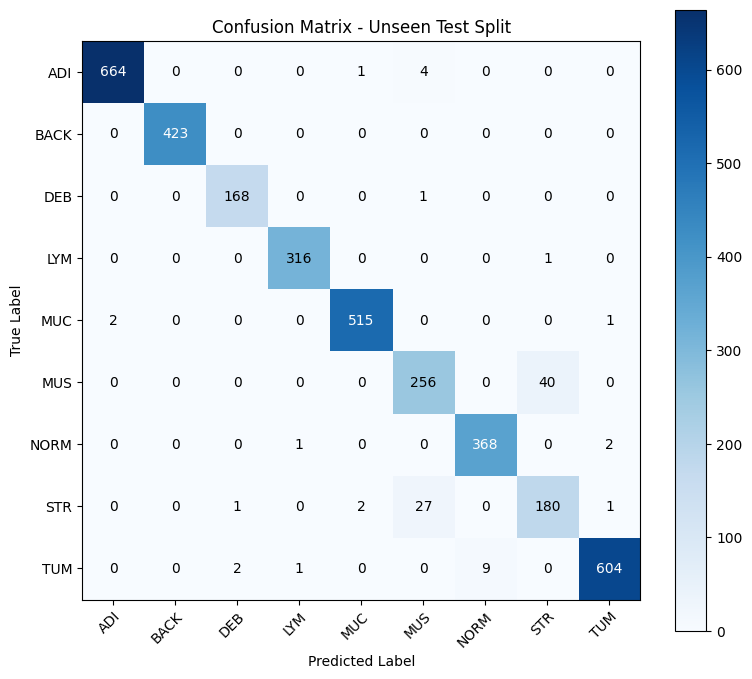

In [10]:

base_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
eval_model = nn.DataParallel(base_model) if n_gpus > 1 else base_model
eval_model.eval()

all_preds, all_true, all_logits = [], [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final test eval"):
        images = images.to(device, non_blocking=True)
        with autocast('cuda'):
            logits = eval_model(images)
        all_logits.append(logits.float().cpu().numpy())
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_true.append(labels.numpy())

all_preds  = np.concatenate(all_preds)
all_true   = np.concatenate(all_true)
all_logits = np.concatenate(all_logits)

test_acc = (all_preds == all_true).mean()
print(f"Final Test Accuracy (CRC-VAL-HE-7K): {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       ylabel='True Label', xlabel='Predicted Label',
       title='Confusion Matrix - Unseen Test Split')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
fig.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_v6.png', dpi=200)
plt.show()


### Temperature scaling: Calibrated on val

In [11]:

def get_val_logits(model, loader):
    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            with autocast('cuda'):
                logits = model(images)
            logits_list.append(logits.float().cpu().numpy())
            labels_list.append(labels.numpy())
    return np.concatenate(logits_list).astype(np.float64), np.concatenate(labels_list)

val_logits, val_true_arr = get_val_logits(eval_model, val_loader)

def nll_temperature_objective(T, logits, labels):
    scaled_logits = logits / T
    exp_l = np.exp(scaled_logits - np.max(scaled_logits, axis=1, keepdims=True))
    probs = np.clip(exp_l / np.sum(exp_l, axis=1, keepdims=True), 1e-12, 1.0)
    one_hot = np.eye(NUM_CLASSES)[labels]
    return -np.mean(np.sum(one_hot * np.log(probs), axis=1))

res = minimize_scalar(lambda T: nll_temperature_objective(T, val_logits, val_true_arr),
                       bounds=(0.05, 5.0), method='bounded')
optimal_temp = float(res.x)

nll_val_uncalibrated = nll_temperature_objective(1.0, val_logits, val_true_arr)
nll_val_calibrated   = nll_temperature_objective(optimal_temp, val_logits, val_true_arr)

print(f"Optimal Temperature: {optimal_temp:.4f}")
print(f"Val NLL: {nll_val_uncalibrated:.4f} -> {nll_val_calibrated:.4f}")
np.save('/kaggle/working/temperature_value_v6.npy', np.array([optimal_temp]))


Optimal Temperature: 0.5655
Val NLL: 0.1960 -> 0.0937


### Grad-CAM++

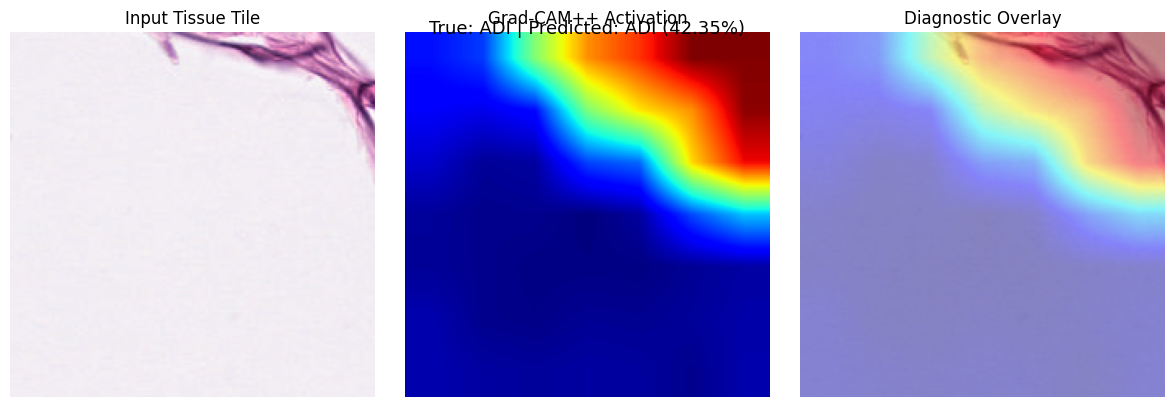

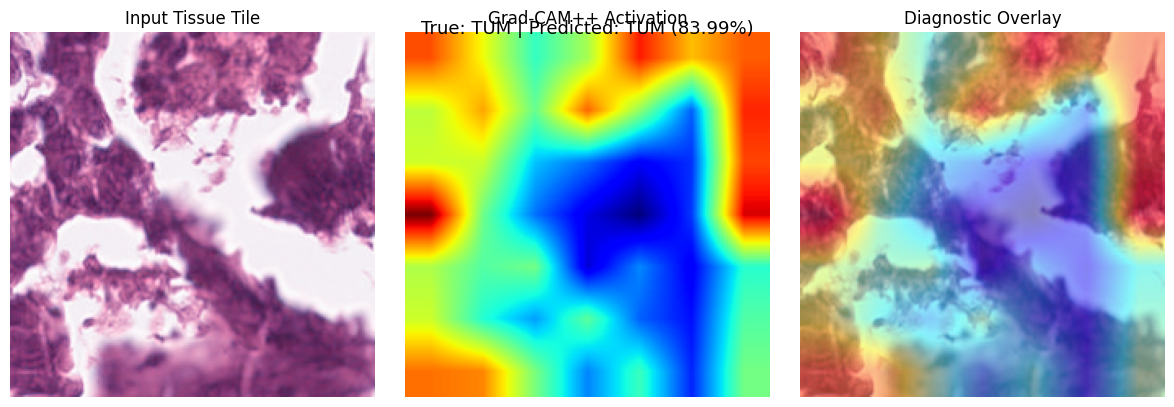

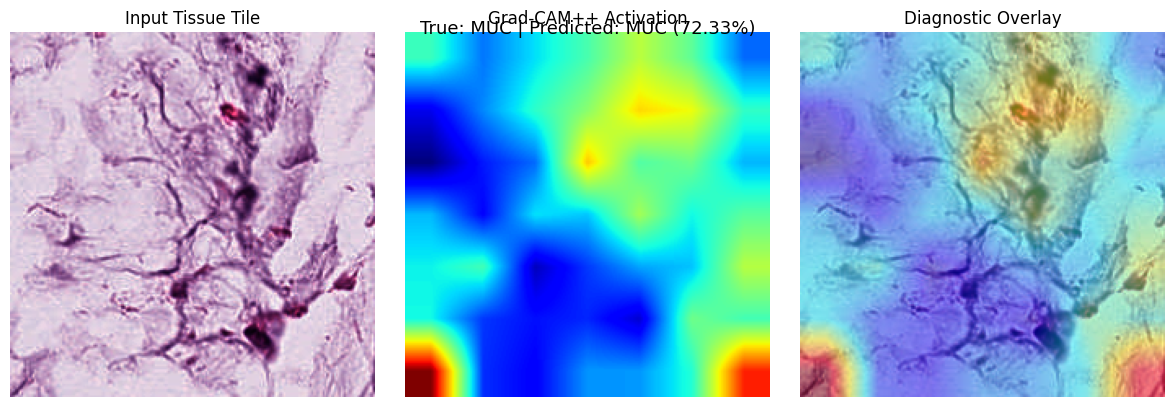

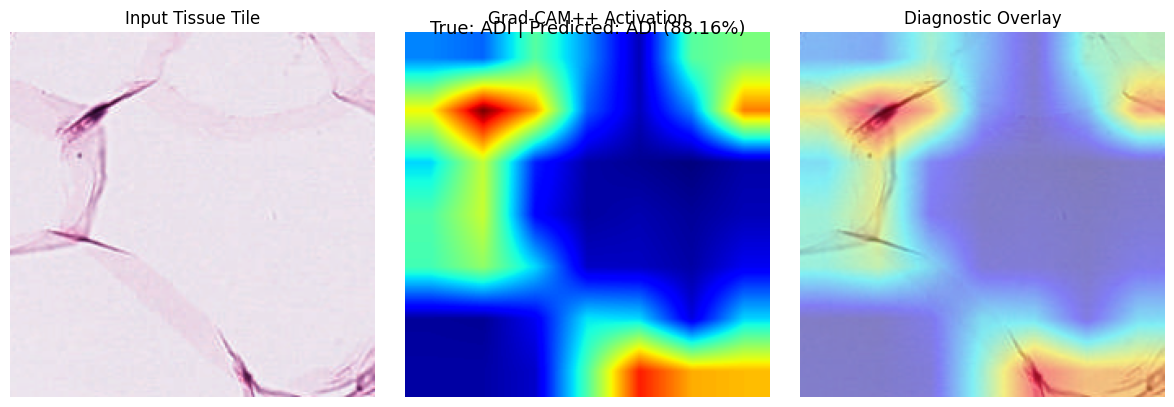

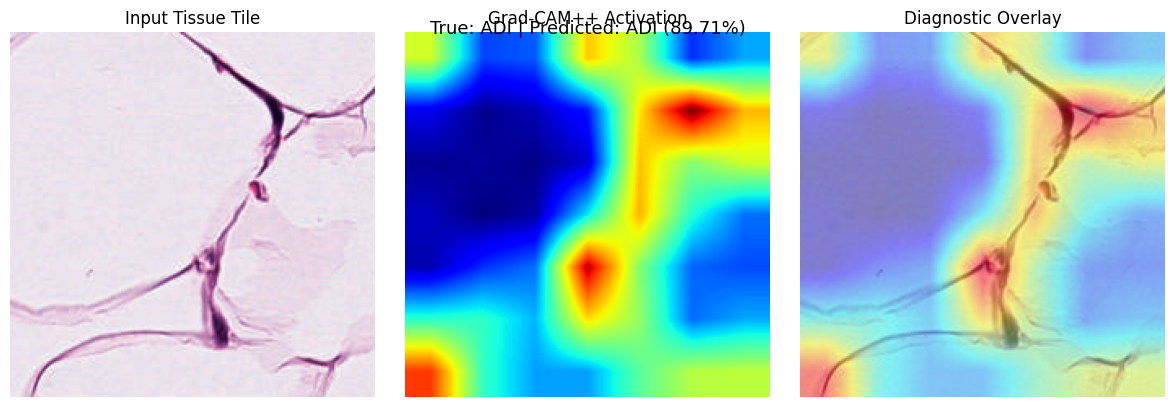

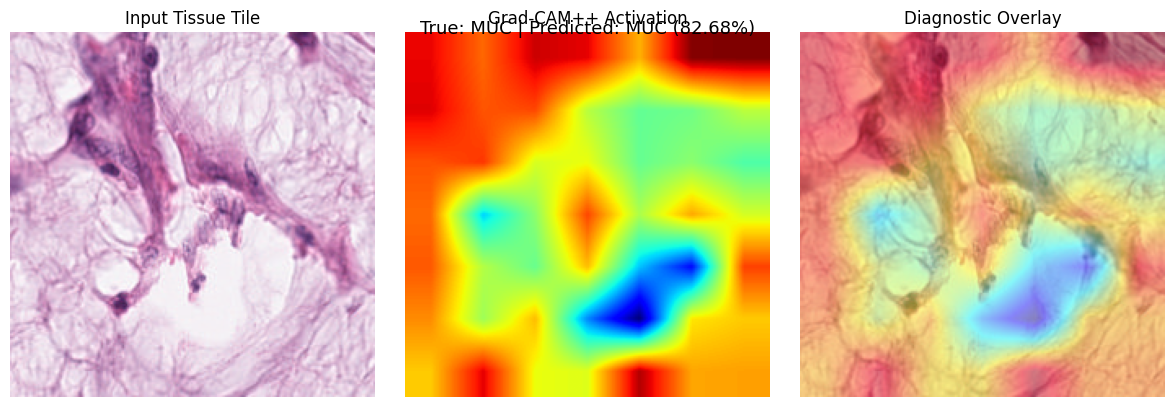


Fallback triggered on 0/6 samples.
If this is frequently > 0, Grad-CAM++ is still unstable for this backbone and vanilla Grad-CAM
(swap the default to vanilla_gradcam) is the more reliable choice for production use.


In [12]:

def swin_gradcam_plus_plus(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device).requires_grad_(False)

    logits = model(image_tensor, capture_map=True)
    probs = F.softmax(logits, dim=1)
    pred_idx = logits.argmax(1).item()
    if target_class is None:
        target_class = pred_idx

    score = logits[0, target_class]
    model.zero_grad()
    score.backward(retain_graph=True)

    feat_map = model.last_feature_map
    grads = feat_map.grad

    feat_map_pos = torch.clamp(feat_map, min=0.0)   # restore the non-negative assumption Grad-CAM++ needs

    grads_pow2 = grads.pow(2)
    grads_pow3 = grads.pow(3)
    eps = 1e-7
    sum_feat = feat_map_pos.sum(dim=(1, 2), keepdim=True)
    denom = 2.0 * grads_pow2 + sum_feat * grads_pow3
    denom = torch.where(denom.abs() < eps, torch.full_like(denom, eps), denom)  # guard near-zero, keep sign
    aij = grads_pow2 / denom
    aij = torch.where(grads != 0, aij, torch.zeros_like(aij))
    aij = torch.clamp(aij, min=0.0, max=1.0)   # keep weighting in a valid, stable range

    weights = torch.clamp(grads, min=0.0) * aij
    alpha = weights.sum(dim=(1, 2))
    cam = torch.einsum('bc,bhwc->bhw', alpha, feat_map_pos)
    cam = F.relu(cam).unsqueeze(1)
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()

    cam_range = cam.max() - cam.min()
    if cam_range < 1e-6:
        cam, pred_idx2, conf2 = vanilla_gradcam(model, image_tensor, target_class=target_class)
        return cam, pred_idx, probs[0, pred_idx].item(), True   # True = fallback was used

    cam = (cam - cam.min()) / (cam_range + 1e-8)
    return cam, pred_idx, probs[0, pred_idx].item(), False


def vanilla_gradcam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device).requires_grad_(False)
    logits = model(image_tensor, capture_map=True)
    pred_idx = logits.argmax(1).item()
    if target_class is None:
        target_class = pred_idx
    model.zero_grad()
    logits[0, target_class].backward()

    feat_map = model.last_feature_map
    grads = feat_map.grad
    weights = grads.mean(dim=(1, 2))
    cam = torch.einsum('bc,bhwc->bhw', weights, feat_map)
    cam = F.relu(cam).unsqueeze(1)
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    probs = F.softmax(logits, dim=1)
    return cam, pred_idx, probs[0, pred_idx].item()


def render_cam_overlay(image_tensor, cam, mean, std, alpha=0.45, used_fallback=False):
    img = image_tensor.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0.0, 1.0)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    overlay = (1 - alpha) * img + alpha * heatmap
    overlay = np.clip(overlay, 0.0, 1.0)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img); axes[0].set_title("Input Tissue Tile"); axes[0].axis('off')
    cam_title = "Grad-CAM (fallback)" if used_fallback else "Grad-CAM++ Activation"
    axes[1].imshow(cam, cmap='jet'); axes[1].set_title(cam_title); axes[1].axis('off')
    axes[2].imshow(overlay); axes[2].set_title("Diagnostic Overlay"); axes[2].axis('off')
    plt.tight_layout()
    return fig


cam_model = base_model
sample_indices = np.random.choice(len(test_ds), size=6, replace=False)   # 6 samples
fallback_count = 0

for idx in sample_indices:
    img_tensor, true_cls = test_ds[idx]
    img_tensor = img_tensor.unsqueeze(0)
    cam, pred_cls, confidence, used_fallback = swin_gradcam_plus_plus(cam_model, img_tensor)
    fallback_count += int(used_fallback)

    fig = render_cam_overlay(img_tensor, cam, NORM_MEAN, NORM_STD, used_fallback=used_fallback)
    fig.suptitle(f"True: {CLASS_NAMES[true_cls]} | Predicted: {CLASS_NAMES[pred_cls]} ({confidence:.2%})"
                 + ("  [fallback used]" if used_fallback else ""), fontsize=13)
    plt.savefig(f'/kaggle/working/gradcam_sample_{idx}.png', dpi=150)
    plt.show()

print(f"\nFallback triggered on {fallback_count}/{len(sample_indices)} samples.")
print("If this is frequently > 0, Grad-CAM++ is still unstable for this backbone and vanilla Grad-CAM")
print("(swap the default to vanilla_gradcam) is the more reliable choice for production use.")


### Save final artifacts

In [13]:

with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

summary = {
    "model_name": "XPathology_ColonSpecialist_CTransPath_v6",
    "architecture": "CTransPath (Swin-Tiny + ConvStem)",
    "base": "your proven v5-optimized run (97.58% test acc) -- unchanged pipeline, fixed Grad-CAM++ only",
    "training_optimization": {
        "data_loading": "Albumentations + OpenCV C++ backend",
        "mixed_precision": "torch.amp.autocast('cuda') (FP16)",
        "phase1_epochs": EPOCHS_PHASE1,
        "phase2_epochs": EPOCHS_PHASE2,
        "learning_rates": {
            "phase1": LR_PHASE1,
            "phase2_backbone": LR_PHASE2_BACKBONE,
            "phase2_head": LR_PHASE2_HEAD
        },
        "scheduler": "CosineAnnealingLR"
    },
    "gradcam_fix": "Grad-CAM++ alpha-weighting computed on ReLU'd features (was signed LayerNorm output) "
                   "with automatic vanilla-Grad-CAM fallback on degenerate output",
    "stain_normalization": "Not used -- deliberate choice, see notebook header for reasoning",
    "metrics": {
        "final_test_accuracy": float(test_acc),
        "calibrated_temperature": float(optimal_temp)
    },
    "normalization": {
        "mean": list(NORM_MEAN),
        "std": list(NORM_STD),
        "image_size": IMG_SIZE
    }
}

with open('/kaggle/working/training_summary_v6.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Export Completed:")
print(f"  Checkpoint:  {CHECKPOINT_PATH}")
print(f"  Temperature: /kaggle/working/temperature_value_v6.npy")
print(f"  Class JSON:  /kaggle/working/class_names.json")
print(f"  Summary:     /kaggle/working/training_summary_v6.json")
print(f"\nFinal test accuracy: {test_acc:.4f}")


Export Completed:
  Checkpoint:  /kaggle/working/xpathology_colon_ctranspath_v6.pt
  Temperature: /kaggle/working/temperature_value_v6.npy
  Class JSON:  /kaggle/working/class_names.json
  Summary:     /kaggle/working/training_summary_v6.json

Final test accuracy: 0.9733
